In [4]:
import os
import json
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt # 顺便加个画图库，后面可视化用

# 检查显卡状态
device = "cuda:1" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:1


In [5]:
MODEL_PATH = "Qwen/Qwen3-8B" 

print(f"Loading model and tokenizer from {MODEL_PATH}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH, 
    torch_dtype=torch.bfloat16, 
    device_map=device,
    trust_remote_code=True
)
model.eval() # 切换到评估模式，关闭 Dropout 等机制

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size
print(f"✅ 模型加载完毕！")
print(f"模型层数: {num_layers}, 隐藏层维度(Hidden Size): {hidden_size}")

Loading model and tokenizer from Qwen/Qwen3-8B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

✅ 模型加载完毕！
模型层数: 36, 隐藏层维度(Hidden Size): 4096


In [6]:
DATA_PATH = "/home/bev/disk4/haoxuan/SpeculativeDecoding/pruningAnalysis/calibration_data/alpaca_calibration_1000.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    calibration_data = json.load(f)

print(f"一共加载了 {len(calibration_data)} 条数据。")

# 提取第一条数据作为我们的“小白鼠”
sample_text = calibration_data[0]
print("\n--- 我们的测试文本 ---")
print(sample_text)

一共加载了 1000 条数据。

--- 我们的测试文本 ---
Instruction: Give three tips for staying healthy.
Answer: 1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.


In [7]:
# 将文本转化为 Token ID
inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=2048).to(device)

input_ids = inputs["input_ids"]
seq_len = input_ids.shape[1]

print(f"Token IDs Shape: {input_ids.shape}")
print(f"这意味着：Batch Size = {input_ids.shape[0]}, Sequence Length (句子长度) = {seq_len} 个 Token。")

Token IDs Shape: torch.Size([1, 55])
这意味着：Batch Size = 1, Sequence Length (句子长度) = 55 个 Token。


In [8]:
with torch.no_grad():
    # 开始前向传播！
    outputs = model(**inputs, output_hidden_states=True)

# 提取隐藏状态
hidden_states = outputs.hidden_states

print(f"获取到的 hidden_states 是一个 tuple，它的长度是: {len(hidden_states)}")
print("💡 思考：为什么 36 层的模型，tuple 长度是 37？")
print("答：因为索引 0 是 Embedding 层（即输入到第 1 层之前的初始特征），索引 1~36 才是每一层 Transformer Block 的输出。")
# print(hidden_states)
# 观察某一层张量的形状
layer_0_output = hidden_states[0]
print(f"\n第 0 层 (Embedding层) 输出张量形状: {layer_0_output.shape}")
print("形状解析: [batch_size, sequence_length, hidden_dim]")
layer_1_output = hidden_states[1]
print(f"\n the first layer 's output hidden state size {layer_1_output.shape}")
layer_1_output

获取到的 hidden_states 是一个 tuple，它的长度是: 37
💡 思考：为什么 36 层的模型，tuple 长度是 37？
答：因为索引 0 是 Embedding 层（即输入到第 1 层之前的初始特征），索引 1~36 才是每一层 Transformer Block 的输出。

第 0 层 (Embedding层) 输出张量形状: torch.Size([1, 55, 4096])
形状解析: [batch_size, sequence_length, hidden_dim]

 the first layer 's output hidden state size torch.Size([1, 55, 4096])


tensor([[[-0.1289,  0.2012,  0.0334,  ...,  0.5352, -0.0210,  0.2520],
         [-0.0381,  0.1230, -0.0569,  ..., -0.0688,  0.0157,  0.0515],
         [ 0.1348, -0.1943, -0.0007,  ..., -0.0432, -0.0106, -0.0103],
         ...,
         [-0.1396, -0.0457,  0.0947,  ...,  0.1172, -0.1562, -0.0247],
         [-0.0532, -0.0337, -0.0041,  ...,  0.1621,  0.0684, -0.0830],
         [-0.0200,  0.0525, -0.0088,  ..., -0.0099, -0.0150,  0.0131]]],
       device='cuda:1', dtype=torch.bfloat16)

In [9]:
# 取出第15层和第16层的输出
layer_15_out = hidden_states[15] # 这是第16层的输入
layer_16_out = hidden_states[16] # 这是第16层的输出

# 我们沿着隐藏层的维度 (dim=-1，即最后的 4096 维度) 计算余弦相似度
# 这会得到每个 token 在这一层前后变化的相似度
token_similarities = F.cosine_similarity(layer_15_out, layer_16_out, dim=-1)

print(f"Token similarities 形状: {token_similarities.shape}") # 应该是 [1, seq_len]

# 对所有 token 取平均，得到整个句子在这一层的平均冗余度
layer_16_redundancy = token_similarities.mean().item()
print(f"✨ 第 16 层的平均余弦相似度 (冗余度): {layer_16_redundancy:.4f}")

Token similarities 形状: torch.Size([1, 55])
✨ 第 16 层的平均余弦相似度 (冗余度): 0.9648


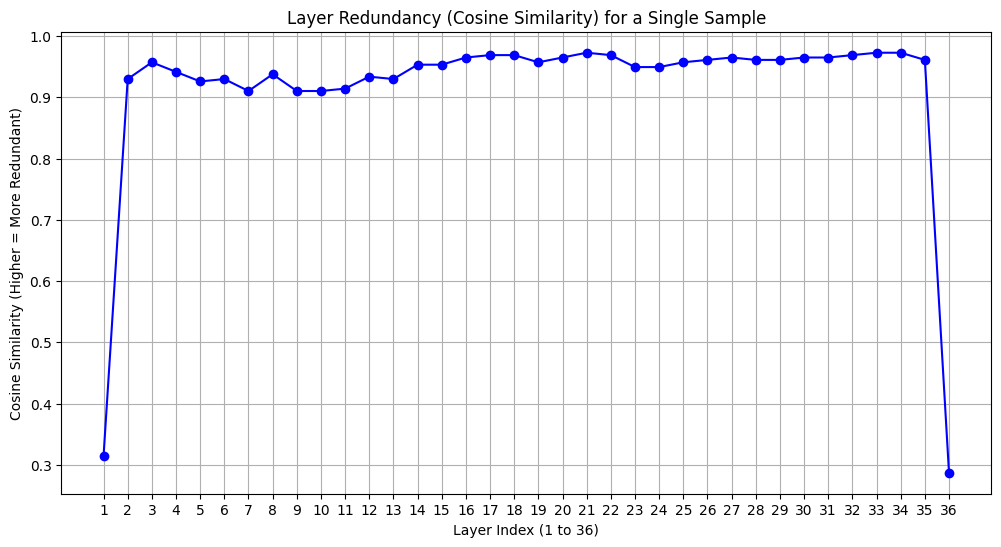

In [10]:
single_sample_sims = []

for i in range(1, num_layers + 1):
    in_state = hidden_states[i-1]
    out_state = hidden_states[i]
    sim = F.cosine_similarity(in_state, out_state, dim=-1).mean().item()
    single_sample_sims.append(sim)

# 画图
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_layers + 1), single_sample_sims, marker='o', linestyle='-', color='b')
plt.title("Layer Redundancy (Cosine Similarity) for a Single Sample")
plt.xlabel("Layer Index (1 to 36)")
plt.ylabel("Cosine Similarity (Higher = More Redundant)")
plt.grid(True)
plt.xticks(range(1, num_layers + 1))
plt.show()

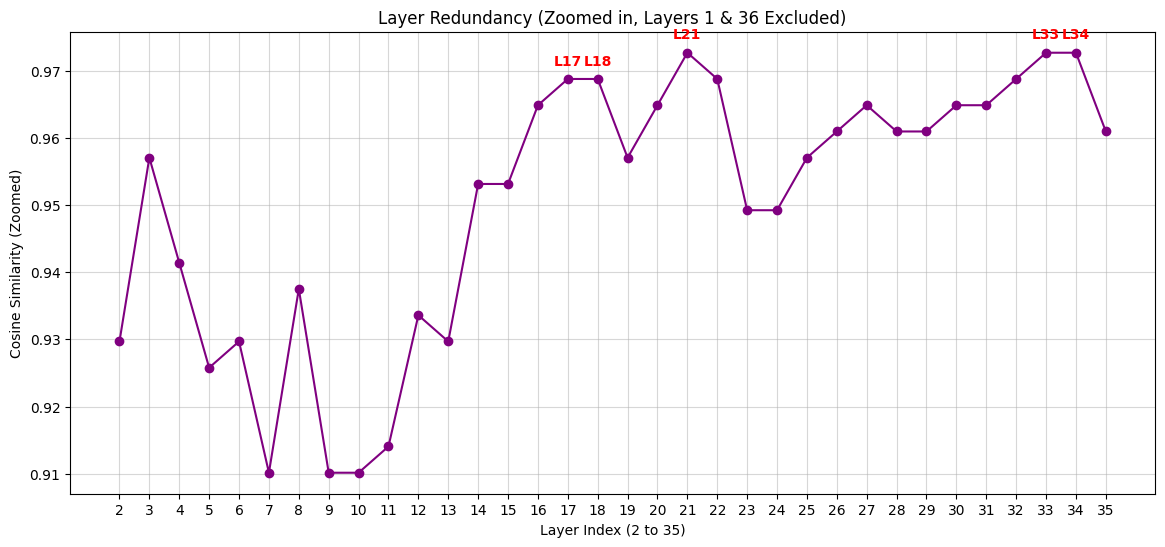

In [14]:
# 忽略掉两头极端的第1层和第36层，放大观察中间层的微小波动
filtered_layers_sim = list(range(2, num_layers)) # 也就是 Layer 2 到 35
filtered_sims = single_sample_sims[1:-1] # 列表切片：去掉第一个和最后一个元素

plt.figure(figsize=(14, 6))
# 换个颜色区分一下
plt.plot(filtered_layers_sim, filtered_sims, marker='o', linestyle='-', color='purple')
plt.title("Layer Redundancy (Zoomed in, Layers 1 & 36 Excluded)")
plt.xlabel("Layer Index (2 to 35)")
plt.ylabel("Cosine Similarity (Zoomed)")
plt.grid(True, alpha=0.5)
plt.xticks(filtered_layers_sim)

# 自动在图中标出最冗余（相似度最高）的几个层，方便你直接看结果
top_redundant = sorted(zip(filtered_layers_sim, filtered_sims), key=lambda x: x[1], reverse=True)[:5]
for layer, sim in top_redundant:
    plt.annotate(f"L{layer}", (layer, sim), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')

plt.show()

In [13]:
from tqdm.notebook import tqdm # Jupyter 专用的进度条

layer_similarities = {i: 0.0 for i in range(1, num_layers + 1)}
num_samples = 1000 # 我们测 1000 条

with torch.no_grad():
    for text in tqdm(calibration_data[:num_samples], desc="Analyzing Layers"):
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(device)
        outputs = model(**inputs, output_hidden_states=True)
        h_states = outputs.hidden_states
        
        for i in range(1, num_layers + 1):
            sim = F.cosine_similarity(h_states[i-1], h_states[i], dim=-1).mean().item()
            layer_similarities[i] += sim

# 计算平均值
for i in range(1, num_layers + 1):
    layer_similarities[i] /= num_samples

# 排序并得出结果
sorted_layers = sorted(layer_similarities.items(), key=lambda x: x[1], reverse=True)
layers_to_prune = sorted([layer_idx for layer_idx, _ in sorted_layers[:18]])
layers_to_keep = sorted([layer_idx for layer_idx, _ in sorted_layers[18:]])

print("\n✂️  最终剪枝方案 (Top 18 最冗余层)")
print(f"建议剪除的层 (Prune): {layers_to_prune}")
print(f"建议保留的层 (Keep) : {layers_to_keep}")

Analyzing Layers:   0%|          | 0/1000 [00:00<?, ?it/s]


✂️  最终剪枝方案 (Top 18 最冗余层)
建议剪除的层 (Prune): [3, 16, 17, 18, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
建议保留的层 (Keep) : [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 19, 23, 24, 36]
